# Group 5 Capstone Starter Notebook

## 2024 Home Mortgage Disclosure Act (HMDA): Loan/Application Records (LAR)

- 1. Place raw data in `data/raw/`.
- 2. Save cleaned datasets in `data/processed/`.



Use this notebook for initial exploration, data checks, and quick experiments. Move reusable code into `src/` as the project matures.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive
import zipfile
import csv
sns.set_theme(style="whitegrid")
# Mount Google Drive
# drive.mount('/content/drive')

In [2]:
# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from google.colab import drive
# import zipfile
# import csv
# sns.set_theme(style="whitegrid")
# # Mount Google Drive
# drive.mount('/content/drive')

def clean_data(df):
    """Clean HMDA LAR data and create target label from action_taken.
    Converts action_taken to numeric.
    Keeps only records where action_taken is 1, 2, or 3.
    Creates label as:
    1 for action_taken in {1, 2}
    0 for action_taken == 3
    Filters out all other action_taken values (4, 5, 6, 7, 8, etc.).
    """
    print(f"Records before action_taken filter: {len(df)}")
    print(f"Columns before cleaning: {set(df.columns)}")

    if "action_taken" not in df.columns:
        raise ValueError("Required column 'action_taken' is missing from input data.")

    df["action_taken"] = pd.to_numeric(df["action_taken"], errors="coerce")
    df = df[df["action_taken"].isin([1, 2, 3])].copy()
    df["action_taken"] = df["action_taken"].map({1: 1, 2: 1, 3: 0}).astype(int)

    print("Data cleaned successfully")
    print(f"Records retained after action_taken filter: {len(df)}")
    print(f"Columns after cleaning: {set(df.columns)}")
    return df

def download_data(url_link, colab_zipfile_path, zipfileName):
  # Ensure the target directory exists before downloading
  if not colab_zipfile_path.exists():
      colab_zipfile_path.mkdir(parents=True, exist_ok=True)

  # Construct the full path for the downloaded zip file
  download_target_path = colab_zipfile_path / zipfileName

  # Check if the file already exists to avoid re-downloading
  if not download_target_path.exists():
      print(f"Downloading {zipfileName} from {url_link} to {colab_zipfile_path}")
      !wget -O "{download_target_path}" "{url_link}"
      print("Download complete.")
  else:
      print(f"File {zipfileName} already exists at {download_target_path}. Skipping download.")

def getZipfile(RAW_DIR, zipfileName):
  # This function now correctly returns the Path object for the zip file in Google Drive
  return RAW_DIR / zipfileName


def unzpip_file(zip_path, extract_to):
    """Unzip a file to the specified directory."""
    try:
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"File {zip_path} extracted successfully to {extract_to}")
    except Exception as e:
        print(f"Error extracting file: {e}")
        return None

def find_input_file(raw_dir, base_name="hmda_lar_2024"):
    """Find a likely HMDA LAR input file by name pattern and extension."""
    supported_ext = [".csv", ".txt"]

    # 1) Exact base-name match first
    for ext in supported_ext:
        candidate = raw_dir / f"{base_name}{ext}"
        if candidate.exists():
            return candidate

    # 2) Flexible match (handles names like 2024_lar.txt)
    candidates = [
        p for p in sorted(raw_dir.glob("*"))
        if p.is_file() and p.suffix.lower() in supported_ext
    ]

    def score_file(path_obj):
        name = path_obj.stem.lower()
        score = 0
        if "hmda" in name:
            score += 3
        if "lar" in name:
            score += 3
        if "2024" in name:
            score += 2
        if name == base_name.lower():
            score += 10
        return score

    ranked = sorted(candidates, key=score_file, reverse=True)
    if ranked and score_file(ranked[0]) > 0:
        return ranked[0]

    return None

def detect_delimiter(file_path):
    """Infer delimiter from extension, then validate using csv.Sniffer with fallback counting."""
    ext_default = {
        ".csv": ",",
        ".tsv": "\t",
        ".txt": "|",
        ".psv": "|",
    }
    delimiter = ext_default.get(file_path.suffix.lower(), ",")

    try:
        with open(file_path, "r", encoding="utf-8", newline="") as f:
            # Read only a sample to determine delimiter
            sample_lines = []
            for i, line in enumerate(f):
                sample_lines.append(line)
                if i >= 4: # Read first 5 lines
                    break
            sample = "".join(sample_lines)

        if sample.strip():
            try:
                dialect = csv.Sniffer().sniff(sample, delimiters=[",", "\t", "|", ";"])
                delimiter = dialect.delimiter
            except Exception:
                # Fallback: choose delimiter with highest count in first non-empty line
                first_line = next((ln for ln in sample.splitlines() if ln.strip()), "")
                delimiter_counts = {
                    ",": first_line.count(","),
                    "\t": first_line.count("\t"),
                    "|": first_line.count("|"),
                    ";": first_line.count(";"),
                }
                best_delimiter = max(delimiter_counts, key=delimiter_counts.get)
                if delimiter_counts[best_delimiter] > 0:
                    delimiter = best_delimiter
    except Exception as e:
        print(f"Could not inspect delimiter, using '{delimiter}'. Reason: {e}")

    return delimiter

def load_data(file_path, delimiter='|'):
    """Load HMDA LAR data using the detected delimiter."""
    if not file_path.exists():
        print(f"Error: File {file_path} does not exist. Cannot load data.")
        return None
    try:
        print(f"Loading data from {file_path} with delimiter '{delimiter}'")
        df = pd.read_csv(file_path, sep=delimiter, low_memory=False)
        print(f"Data loaded successfully from {file_path} with delimiter '{delimiter}'")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None


def main():

    # Define paths relative to the current working directory
    project_root = Path.cwd()
    if project_root.name == "notebooks":
        project_root = project_root.parent

    RAW_DIR = project_root / "data" / "raw"
    PROCESSED_DIR = project_root / "data" / "processed"

    # Create directories if they don't exist
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    # Define the base path in Google Drive for the zip file and its name
    colab_zipfile_path = Path("/data/raw")
    zipfileName = "2024_lar.zip"

    print(f"RAW_DIR: {RAW_DIR}")
    print(f"PROCESSED_DIR: {PROCESSED_DIR}")
    print(f"colab_zipfile_path: {colab_zipfile_path}")
    print(f"zipfileName: {zipfileName}")

    # Define URL for data download
    url_link = "https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip"

    processed_file = PROCESSED_DIR / "hmda_lar_2024_cleaned.csv"

    # Check if cleaned data already exists
    if processed_file.exists():
        print(f"Cleaned data already exists at {processed_file}. Loading existing file.")
        df_cleaned = pd.read_csv(processed_file, low_memory=False)
        print(f"Cleaned data loaded successfully from {processed_file}")
        print("\n--- Summary of Existing Cleaned Data ---")
        display(df_cleaned.head())
        df_cleaned.info()
        display(df_cleaned.describe(include='all'))
        print(f"Shape of cleaned data: {df_cleaned.shape}")
        print(f"Columns in cleaned data: {list(df_cleaned.columns)}")
        return # Exit main function, as all steps are done

    print("Cleaned data not found, proceeding with download, unzip, load, and clean process.")

    # 1. Download the data from the URL to Google Drive if it doesn't exist
    download_data(url_link, RAW_DIR, zipfileName)

    # 2. Get the full path to the downloaded zip file in Google Drive
    filepath = getZipfile(RAW_DIR, zipfileName)
    print(f"Zip file in Drive: {filepath}")

    # 3. Unzip the downloaded file from Google Drive to the local RAW_DIR
    # Check if the raw data file (expected after unzip) already exists in RAW_DIR
    raw_file_in_raw_dir = find_input_file(RAW_DIR, base_name="2024_lar")

    if filepath.exists():
        if raw_file_in_raw_dir:
            print(f"Extracted file {raw_file_in_raw_dir.name} already found in {RAW_DIR}. Skipping unzip.")
        else:
            print(f"Unzipping {filepath} to {RAW_DIR}")
            unzpip_file(filepath, RAW_DIR)
    else:
        print(f"Warning: Zip file not found at {filepath}. Cannot proceed with unzip or data processing.")
        print("Please ensure the download was successful or data is already extracted to RAW_DIR.")
        return # Exit if zip file not found

    # 4. Find source file and infer delimiter before reading from RAW_DIR
    raw_file = find_input_file(RAW_DIR, base_name="2024_lar")
    if raw_file is None:
        available = [p.name for p in sorted(RAW_DIR.glob("*")) if p.is_file()]
        print(f"No supported HMDA LAR file found in {RAW_DIR}.")
        print(f"Available files: {available}")
        print("Data loading or cleaning cannot proceed.")
        return
    else:
        print(f"Found input file: {raw_file}")

    print(f"Selected input file: {raw_file.name}")
    delimiter = '|'  # detect_delimiter(raw_file)
    print(f"Detected delimiter: {repr(delimiter)}")

    df_raw = load_data(raw_file, delimiter)

    if df_raw is not None:
        df_cleaned = clean_data(df_raw)
        if df_cleaned is not None:
            # Save the cleaned data
            df_cleaned.to_csv(processed_file, index=False)
            print(f"Cleaned data saved to {processed_file}")
            print("\n--- Summary of Newly Cleaned Data ---")
            display(df_cleaned.head())
            df_cleaned.info()
            display(df_cleaned.describe(include='all'))
            print(f"Shape of cleaned data: {df_cleaned.shape}")
            print(f"Columns in cleaned data: {list(df_cleaned.columns)}")
        else:
            print("Data cleaning failed. No cleaned data to save.")
    else:
        print("Raw data loading failed, so cleaning and saving were skipped.")

In [3]:
 # Define paths relative to the current working directory
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
print(f"Project root directory: {project_root}")
RAW_DIR = project_root / "data" / "raw"
print(f"RAW_DIR: {RAW_DIR}")
PROCESSED_DIR = project_root / "data" / "processed"
print(f"PROCESSED_DIR: {PROCESSED_DIR}")

Project root directory: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project
RAW_DIR: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/raw
PROCESSED_DIR: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/processed


In [4]:
if __name__ == "__main__":
    main()

RAW_DIR: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/raw
PROCESSED_DIR: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/processed
colab_zipfile_path: /data/raw
zipfileName: 2024_lar.zip
Cleaned data not found, proceeding with download, unzip, load, and clean process.
File 2024_lar.zip already exists at /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/raw/2024_lar.zip. Skipping download.
Zip file in Drive: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/raw/2024_lar.zip
Extracted file 2024_lar.txt already found in /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/data/raw. Skipping unzip.
Found input file: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Pr

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
1,2024,254900ZFWS2106HWPH46,99999,IN,18093.0,18093951202,C,VA:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,2528,5.26,81800,117.0,1074,1334,27
5,2024,254900ZFWS2106HWPH46,36740,FL,12095.0,12095016603,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,7516,50.68,90400,123.0,1865,2572,17
8,2024,254900ZFWS2106HWPH46,12054,GA,13063.0,13063040521,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3329,93.03,100900,45.0,501,963,50
11,2024,254900ZFWS2106HWPH46,15804,NJ,34015.0,34015501103,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5513,27.14,117400,111.0,1641,1819,51
12,2024,254900ZFWS2106HWPH46,19124,TX,48113.0,48113014141,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2144,71.41,110300,93.0,253,419,30


<class 'pandas.core.frame.DataFrame'>
Index: 8661739 entries, 1 to 12259110
Data columns (total 99 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  preapp

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
count,8661739.0,8661739,8.661739e+06,8616243,8.573881e+06,8542698,8623947,8661739,8661739,8661739,...,457169.000000,84912.000000,15587.000000,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06
unique,NaN,4910,NaN,54,NaN,83734,3,8,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,549300FGXN1K3HLB1R50,NaN,CA,NaN,48157673202,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,451284,NaN,727912,NaN,3088,8380405,4513222,8125682,5968131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024.0,NaN,3.925076e+04,NaN,2.812007e+04,NaN,NaN,NaN,NaN,NaN,...,4.288209,5.659483,7.931930,4.757208e+03,3.624166e+01,9.927195e+04,1.084533e+02,1.216896e+03,1.645180e+03,3.577981e+01
std,0.0,NaN,2.623584e+04,NaN,1.628385e+04,NaN,NaN,NaN,NaN,NaN,...,2.683906,2.494214,2.052949,2.158563e+03,2.588807e+01,2.352340e+04,4.194402e+01,5.801001e+02,6.892934e+02,1.831502e+01
min,2024.0,NaN,1.018000e+04,NaN,1.001000e+03,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,2024.0,NaN,2.050000e+04,NaN,1.210900e+04,NaN,NaN,NaN,NaN,NaN,...,3.000000,4.000000,9.000000,3.406000e+03,1.538000e+01,8.630000e+04,8.300000e+01,8.180000e+02,1.199000e+03,2.300000e+01
50%,2024.0,NaN,3.346000e+04,NaN,2.713100e+04,NaN,NaN,NaN,NaN,NaN,...,4.000000,5.000000,9.000000,4.518000e+03,2.895000e+01,9.820000e+04,1.040000e+02,1.168000e+03,1.606000e+03,3.500000e+01
75%,2024.0,NaN,4.210000e+04,NaN,4.207100e+04,NaN,NaN,NaN,NaN,NaN,...,6.000000,9.000000,9.000000,5.820000e+03,5.230500e+01,1.100000e+05,1.300000e+02,1.558000e+03,2.045000e+03,4.800000e+01


Shape of cleaned data: (8661739, 99)
Columns in cleaned data: ['activity_year', 'lei', 'derived_msa_md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'combined_loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affor

## Data Exploration of Cleaned HMDA LAR Data

First, let's load the cleaned data and get a general overview.

In [5]:
# Define paths (ensure RAW_DIR and PROCESSED_DIR are accessible)
# project_root = Path.cwd()
# if project_root.name == "notebooks":
#     project_root = project_root.parent

# PROCESSED_DIR = project_root / "data" / "processed"

# Load the cleaned data
processed_file = PROCESSED_DIR / "hmda_lar_2024_cleaned.csv"
df_cleaned = pd.read_csv(processed_file, low_memory=False)

print("Cleaned data loaded successfully.")
display(df_cleaned.head())
df_cleaned.info()
display(df_cleaned.describe(include='all'))

Cleaned data loaded successfully.


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,254900ZFWS2106HWPH46,99999,IN,18093.0,1.809395e+10,C,VA:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,2528,5.26,81800,117.0,1074,1334,27
1,2024,254900ZFWS2106HWPH46,36740,FL,12095.0,1.209502e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,7516,50.68,90400,123.0,1865,2572,17
2,2024,254900ZFWS2106HWPH46,12054,GA,13063.0,1.306304e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3329,93.03,100900,45.0,501,963,50
3,2024,254900ZFWS2106HWPH46,15804,NJ,34015.0,3.401550e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5513,27.14,117400,111.0,1641,1819,51
4,2024,254900ZFWS2106HWPH46,19124,TX,48113.0,4.811301e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2144,71.41,110300,93.0,253,419,30


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661739 entries, 0 to 8661738
Data columns (total 99 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              float64
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  pr

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
count,8661739.0,8661739,8.661739e+06,8616243,8.573881e+06,8.542698e+06,8623947,8661739,8661739,8661739,...,457169.000000,84912.000000,15587.000000,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06,8.661739e+06
unique,NaN,4910,NaN,54,NaN,NaN,3,8,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,549300FGXN1K3HLB1R50,NaN,CA,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,451284,NaN,727912,NaN,NaN,8380405,4513222,8125682,5968131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024.0,NaN,3.925076e+04,NaN,2.812007e+04,2.810551e+10,NaN,NaN,NaN,NaN,...,4.288209,5.659483,7.931930,4.757208e+03,3.624166e+01,9.927195e+04,1.084533e+02,1.216896e+03,1.645180e+03,3.577981e+01
std,0.0,NaN,2.623584e+04,NaN,1.628385e+04,1.628164e+10,NaN,NaN,NaN,NaN,...,2.683906,2.494214,2.052949,2.158563e+03,2.588807e+01,2.352340e+04,4.194402e+01,5.801001e+02,6.892934e+02,1.831502e+01
min,2024.0,NaN,1.018000e+04,NaN,1.001000e+03,1.001020e+09,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,2024.0,NaN,2.050000e+04,NaN,1.210900e+04,1.210902e+10,NaN,NaN,NaN,NaN,...,3.000000,4.000000,9.000000,3.406000e+03,1.538000e+01,8.630000e+04,8.300000e+01,8.180000e+02,1.199000e+03,2.300000e+01
50%,2024.0,NaN,3.346000e+04,NaN,2.713100e+04,2.712304e+10,NaN,NaN,NaN,NaN,...,4.000000,5.000000,9.000000,4.518000e+03,2.895000e+01,9.820000e+04,1.040000e+02,1.168000e+03,1.606000e+03,3.500000e+01
75%,2024.0,NaN,4.210000e+04,NaN,4.207100e+04,4.207101e+10,NaN,NaN,NaN,NaN,...,6.000000,9.000000,9.000000,5.820000e+03,5.230500e+01,1.100000e+05,1.300000e+02,1.558000e+03,2.045000e+03,4.800000e+01


### Correlation Heatmap of Numerical Features

Let's visualize the correlation between numerical features in the cleaned dataset to identify potential relationships.

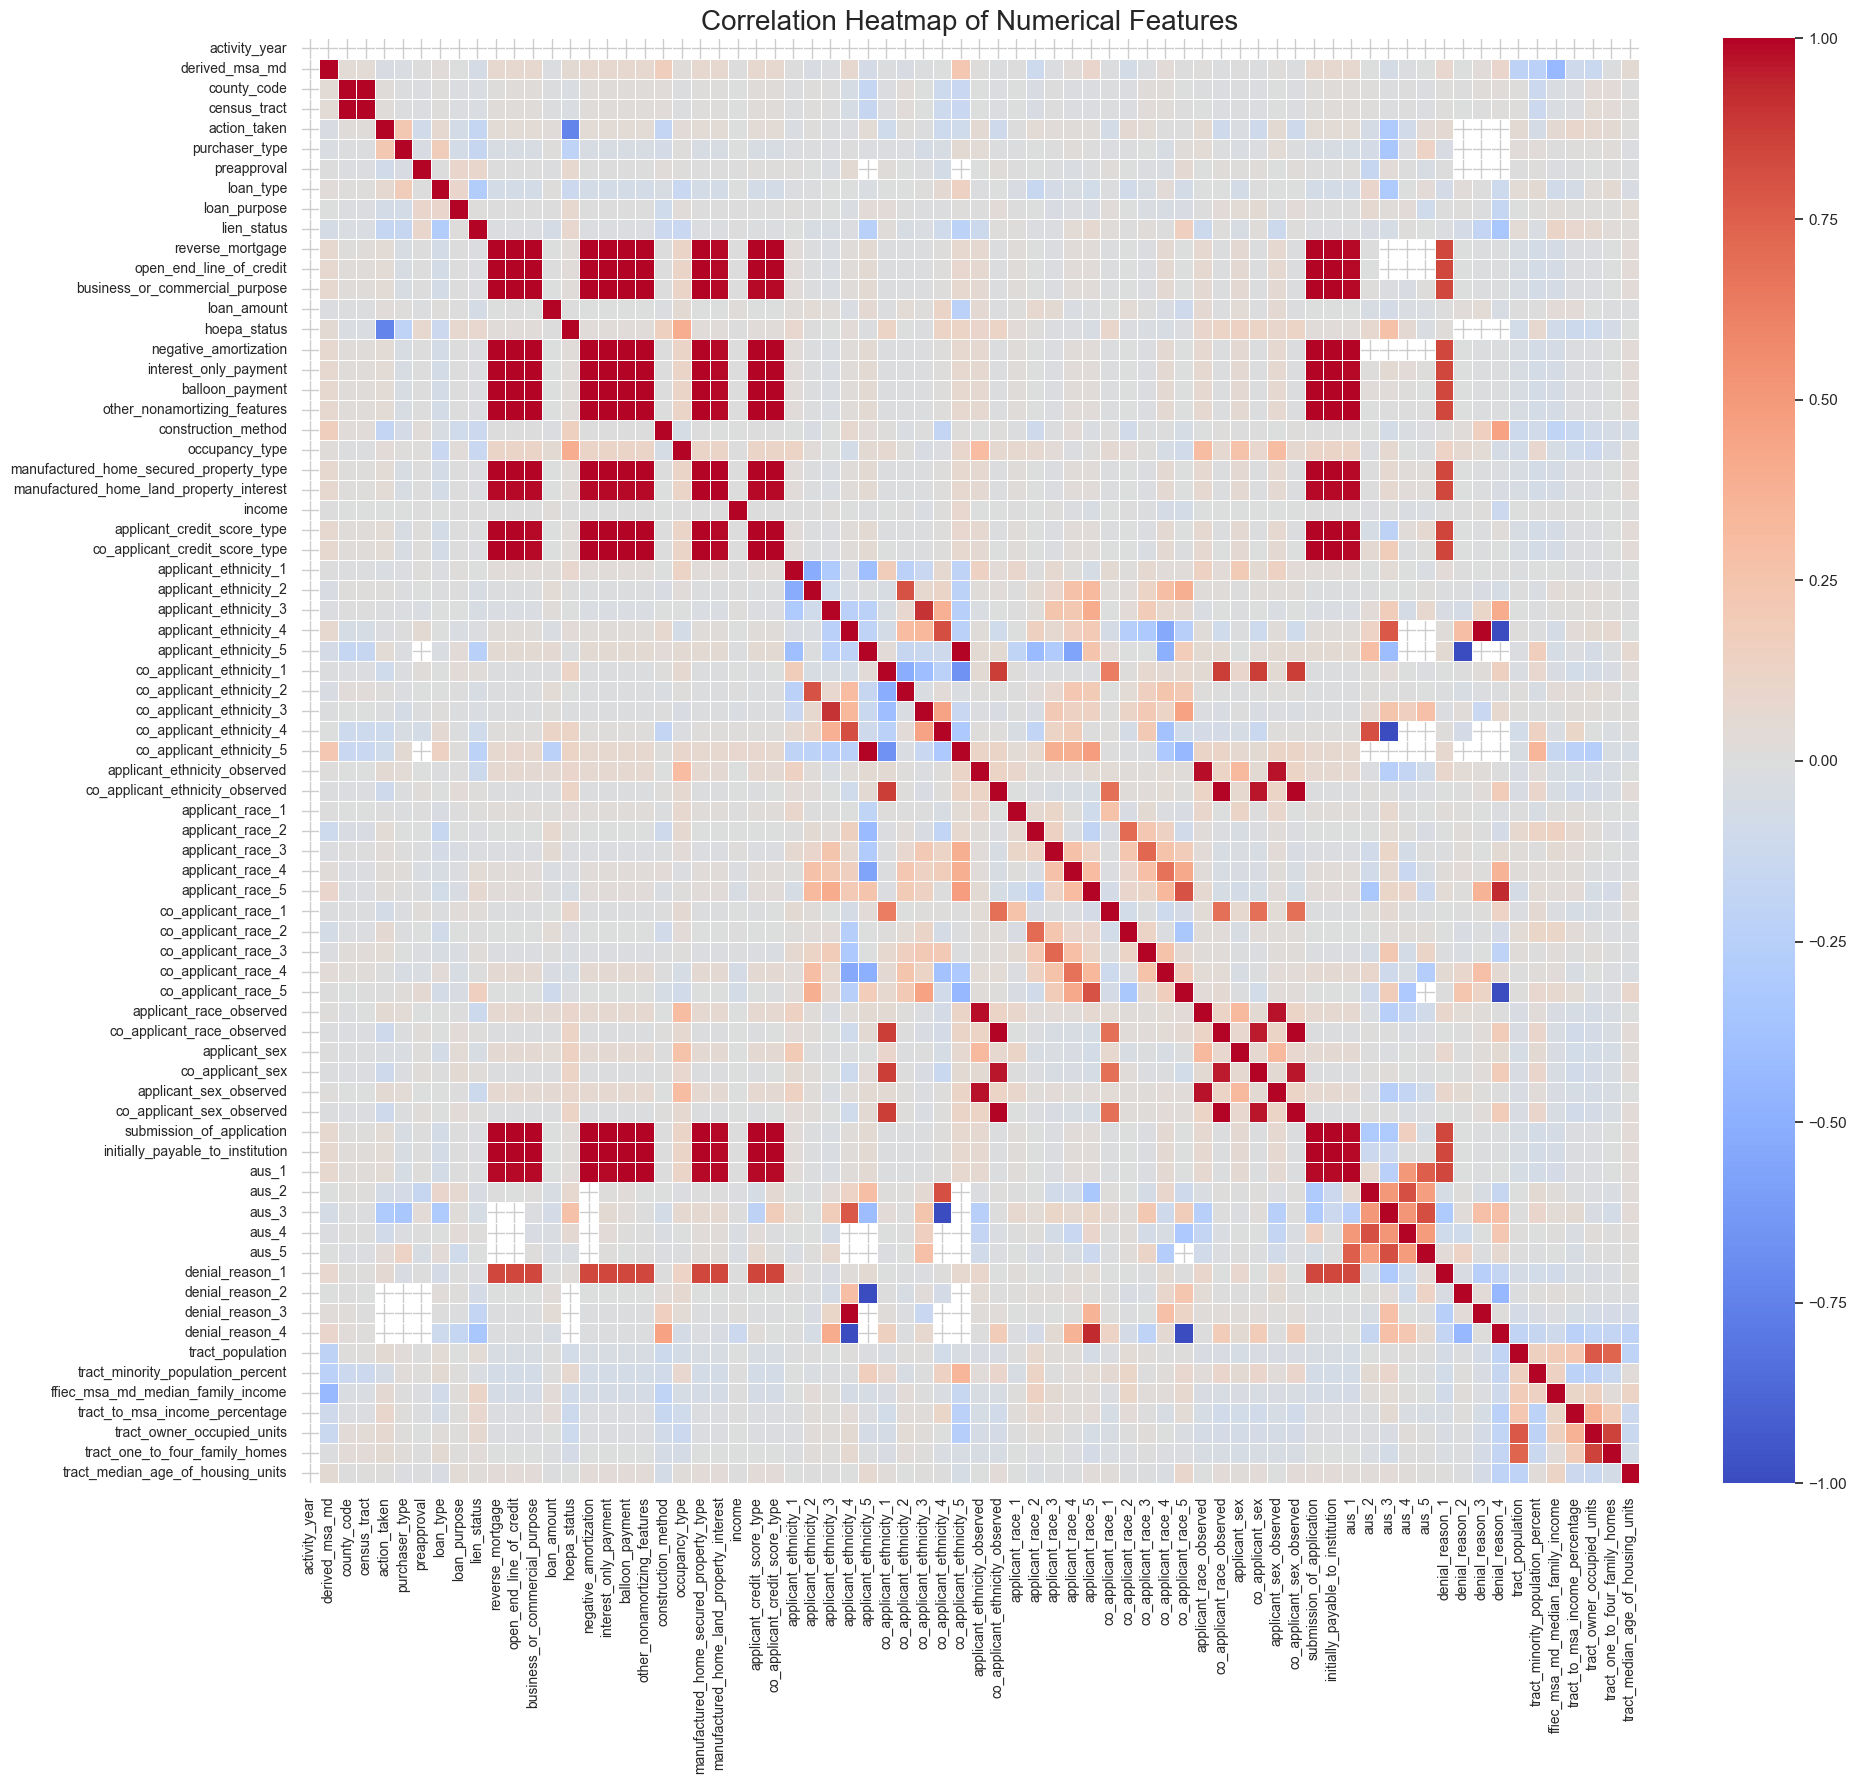

In [6]:
# Ensure df_cleaned is loaded
# project_root = Path.cwd()
# if project_root.name == "notebooks":
#     project_root = project_root.parent

# PROCESSED_DIR = project_root / "data" / "processed"
# processed_file = PROCESSED_DIR / "hmda_lar_2024_cleaned.csv"
# df_cleaned = pd.read_csv(processed_file, low_memory=False)

numerical_cols = df_cleaned.select_dtypes(include=np.number).columns
corr_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

The correlation heatmap for the numerical features in our cleaned data has been successfully generated and displayed. This visualization provides insights into the relationships and dependencies between various numerical attributes in the dataset.

### Missing Values Analysis

Let's check for missing values in the `df_cleaned` DataFrame to understand data completeness.

In [7]:
missing_values = df_cleaned.isnull().sum()
missing_percentage = (missing_values / len(df_cleaned)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

if not missing_info.empty:
    print('Columns with Missing Values and their Percentages:')
    display(missing_info)
else:
    print('No missing values found in the dataset.')

Columns with Missing Values and their Percentages:


,Missing Count,Missing Percentage
co_applicant_ethnicity_5,8661705,99.999607
co_applicant_ethnicity_4,8661637,99.998822
applicant_ethnicity_5,8661631,99.998753
applicant_ethnicity_4,8661392,99.995994
co_applicant_race_5,8660982,99.991260
applicant_race_5,8659877,99.978503
co_applicant_race_4,8659689,99.976333
co_applicant_ethnicity_3,8657764,99.954109
applicant_race_4,8656217,99.936248
applicant_ethnicity_3,8650006,99.864542


The output shows a detailed breakdown of columns with missing data, ordered by the highest percentage of missing values. For instance, co_applicant_ethnicity_5 has almost 100% missing values, while co_applicant_race_1 has a very small percentage of missing values. This information is crucial for deciding on data imputation or feature selection strategies.

In [8]:
initial_cols = df_cleaned.shape[1]

# Calculate missing percentages again to be sure (though missing_info is available)
missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# Identify columns to drop (more than 90% missing)
columns_to_drop = missing_percentage[missing_percentage > 90].index.tolist()

if columns_to_drop:
    print(f"Dropping {len(columns_to_drop)} columns with more than 90% missing values:")
    for col in columns_to_drop:
        print(f"- {col}: {missing_percentage[col]:.2f}%")
    df_cleaned = df_cleaned.drop(columns=columns_to_drop)
    print(f"\nDataFrame shape after dropping columns: {df_cleaned.shape}")
    print(f"Number of columns dropped: {initial_cols - df_cleaned.shape[1]}")
else:
    print("No columns found with more than 90% missing values. No columns dropped.")

Dropping 26 columns with more than 90% missing values:
- total_points_and_fees: 95.85%
- prepayment_penalty_term: 93.39%
- multifamily_affordable_units: 96.83%
- applicant_ethnicity_2: 93.04%
- applicant_ethnicity_3: 99.86%
- applicant_ethnicity_4: 100.00%
- applicant_ethnicity_5: 100.00%
- co_applicant_ethnicity_2: 97.34%
- co_applicant_ethnicity_3: 99.95%
- co_applicant_ethnicity_4: 100.00%
- co_applicant_ethnicity_5: 100.00%
- applicant_race_2: 94.55%
- applicant_race_3: 99.56%
- applicant_race_4: 99.94%
- applicant_race_5: 99.98%
- co_applicant_race_2: 97.86%
- co_applicant_race_3: 99.84%
- co_applicant_race_4: 99.98%
- co_applicant_race_5: 99.99%
- aus_2: 94.06%
- aus_3: 98.14%
- aus_4: 99.09%
- aus_5: 99.18%
- denial_reason_2: 94.72%
- denial_reason_3: 99.02%
- denial_reason_4: 99.82%

DataFrame shape after dropping columns: (8661739, 73)
Number of columns dropped: 26


We dropped 26 columns that had more than 90% missing values. The DataFrame now has 73 columns, down from the initial 99. We decided on this because it helps in streamlining the dataset by removing features with insufficient data, which could otherwise hinder analysis or modeling.

### Distribution of Numerical Columns with Remaining Missing Values

After dropping columns with more than 90% missing values, let's examine the distribution of numerical columns that still have some missing entries. This helps us understand the characteristics of these columns before deciding on imputation methods.

Numerical columns with remaining missing values: ['county_code', 'census_tract', 'income', 'applicant_ethnicity_1', 'co_applicant_ethnicity_1', 'applicant_race_1', 'co_applicant_race_1']


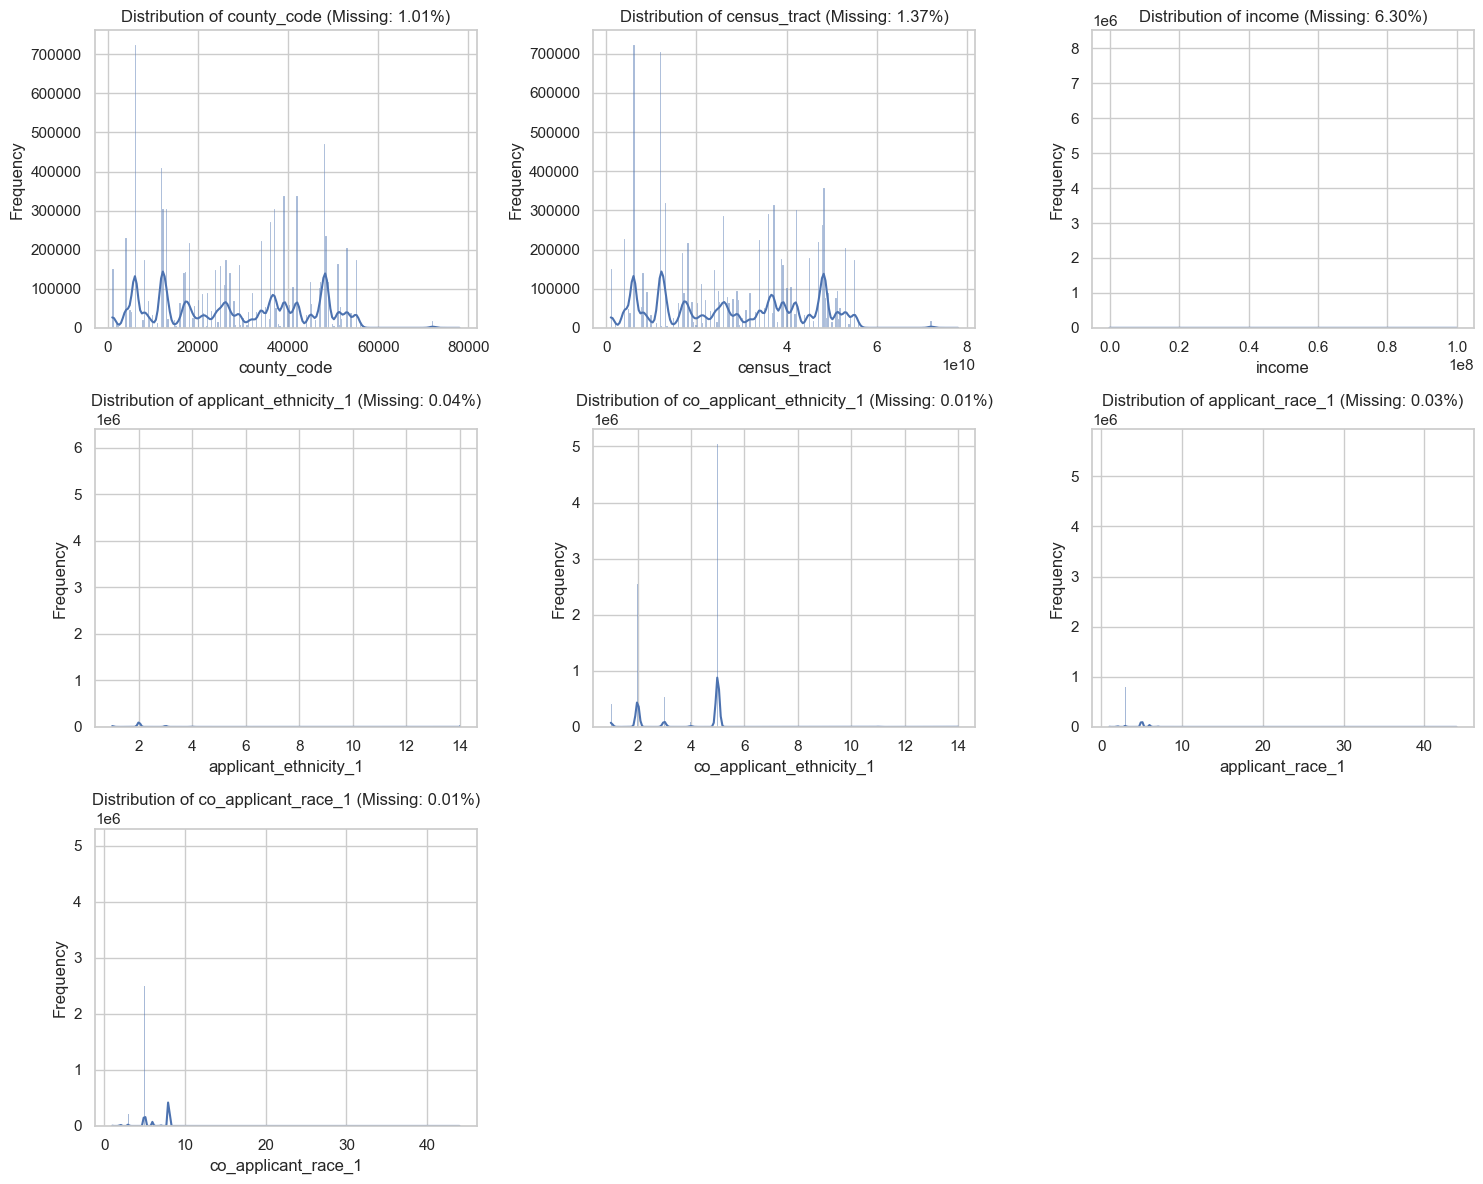

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recalculate missing percentages for the current df_cleaned
missing_percentage_after_drop = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# Filter for numerical columns that still have missing values (percentage > 0)
numerical_missing_cols = df_cleaned.select_dtypes(include=np.number).columns[missing_percentage_after_drop[df_cleaned.select_dtypes(include=np.number).columns] > 0].tolist()

print(f"Numerical columns with remaining missing values: {numerical_missing_cols}")

if numerical_missing_cols:
    # Determine the grid size for subplots
    n_cols = 3  # You can adjust this for desired layout
    n_rows = (len(numerical_missing_cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    for i, col in enumerate(numerical_missing_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(df_cleaned[col].dropna(), kde=True)
        plt.title(f'Distribution of {col} (Missing: {missing_percentage_after_drop[col]:.2f}%)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns with remaining missing values found.")

This is the distributions of the numerical columns with remaining missing values and the columns identified are county_code, census_tract, income, applicant_ethnicity_1, co_applicant_ethnicity_1, applicant_race_1, and co_applicant_race_1.

### Correlation Heatmap for Updated Numerical Features

Let's visualize the correlation between numerical features in the updated `df_cleaned` to identify potential relationships after dropping columns with high missing percentages.

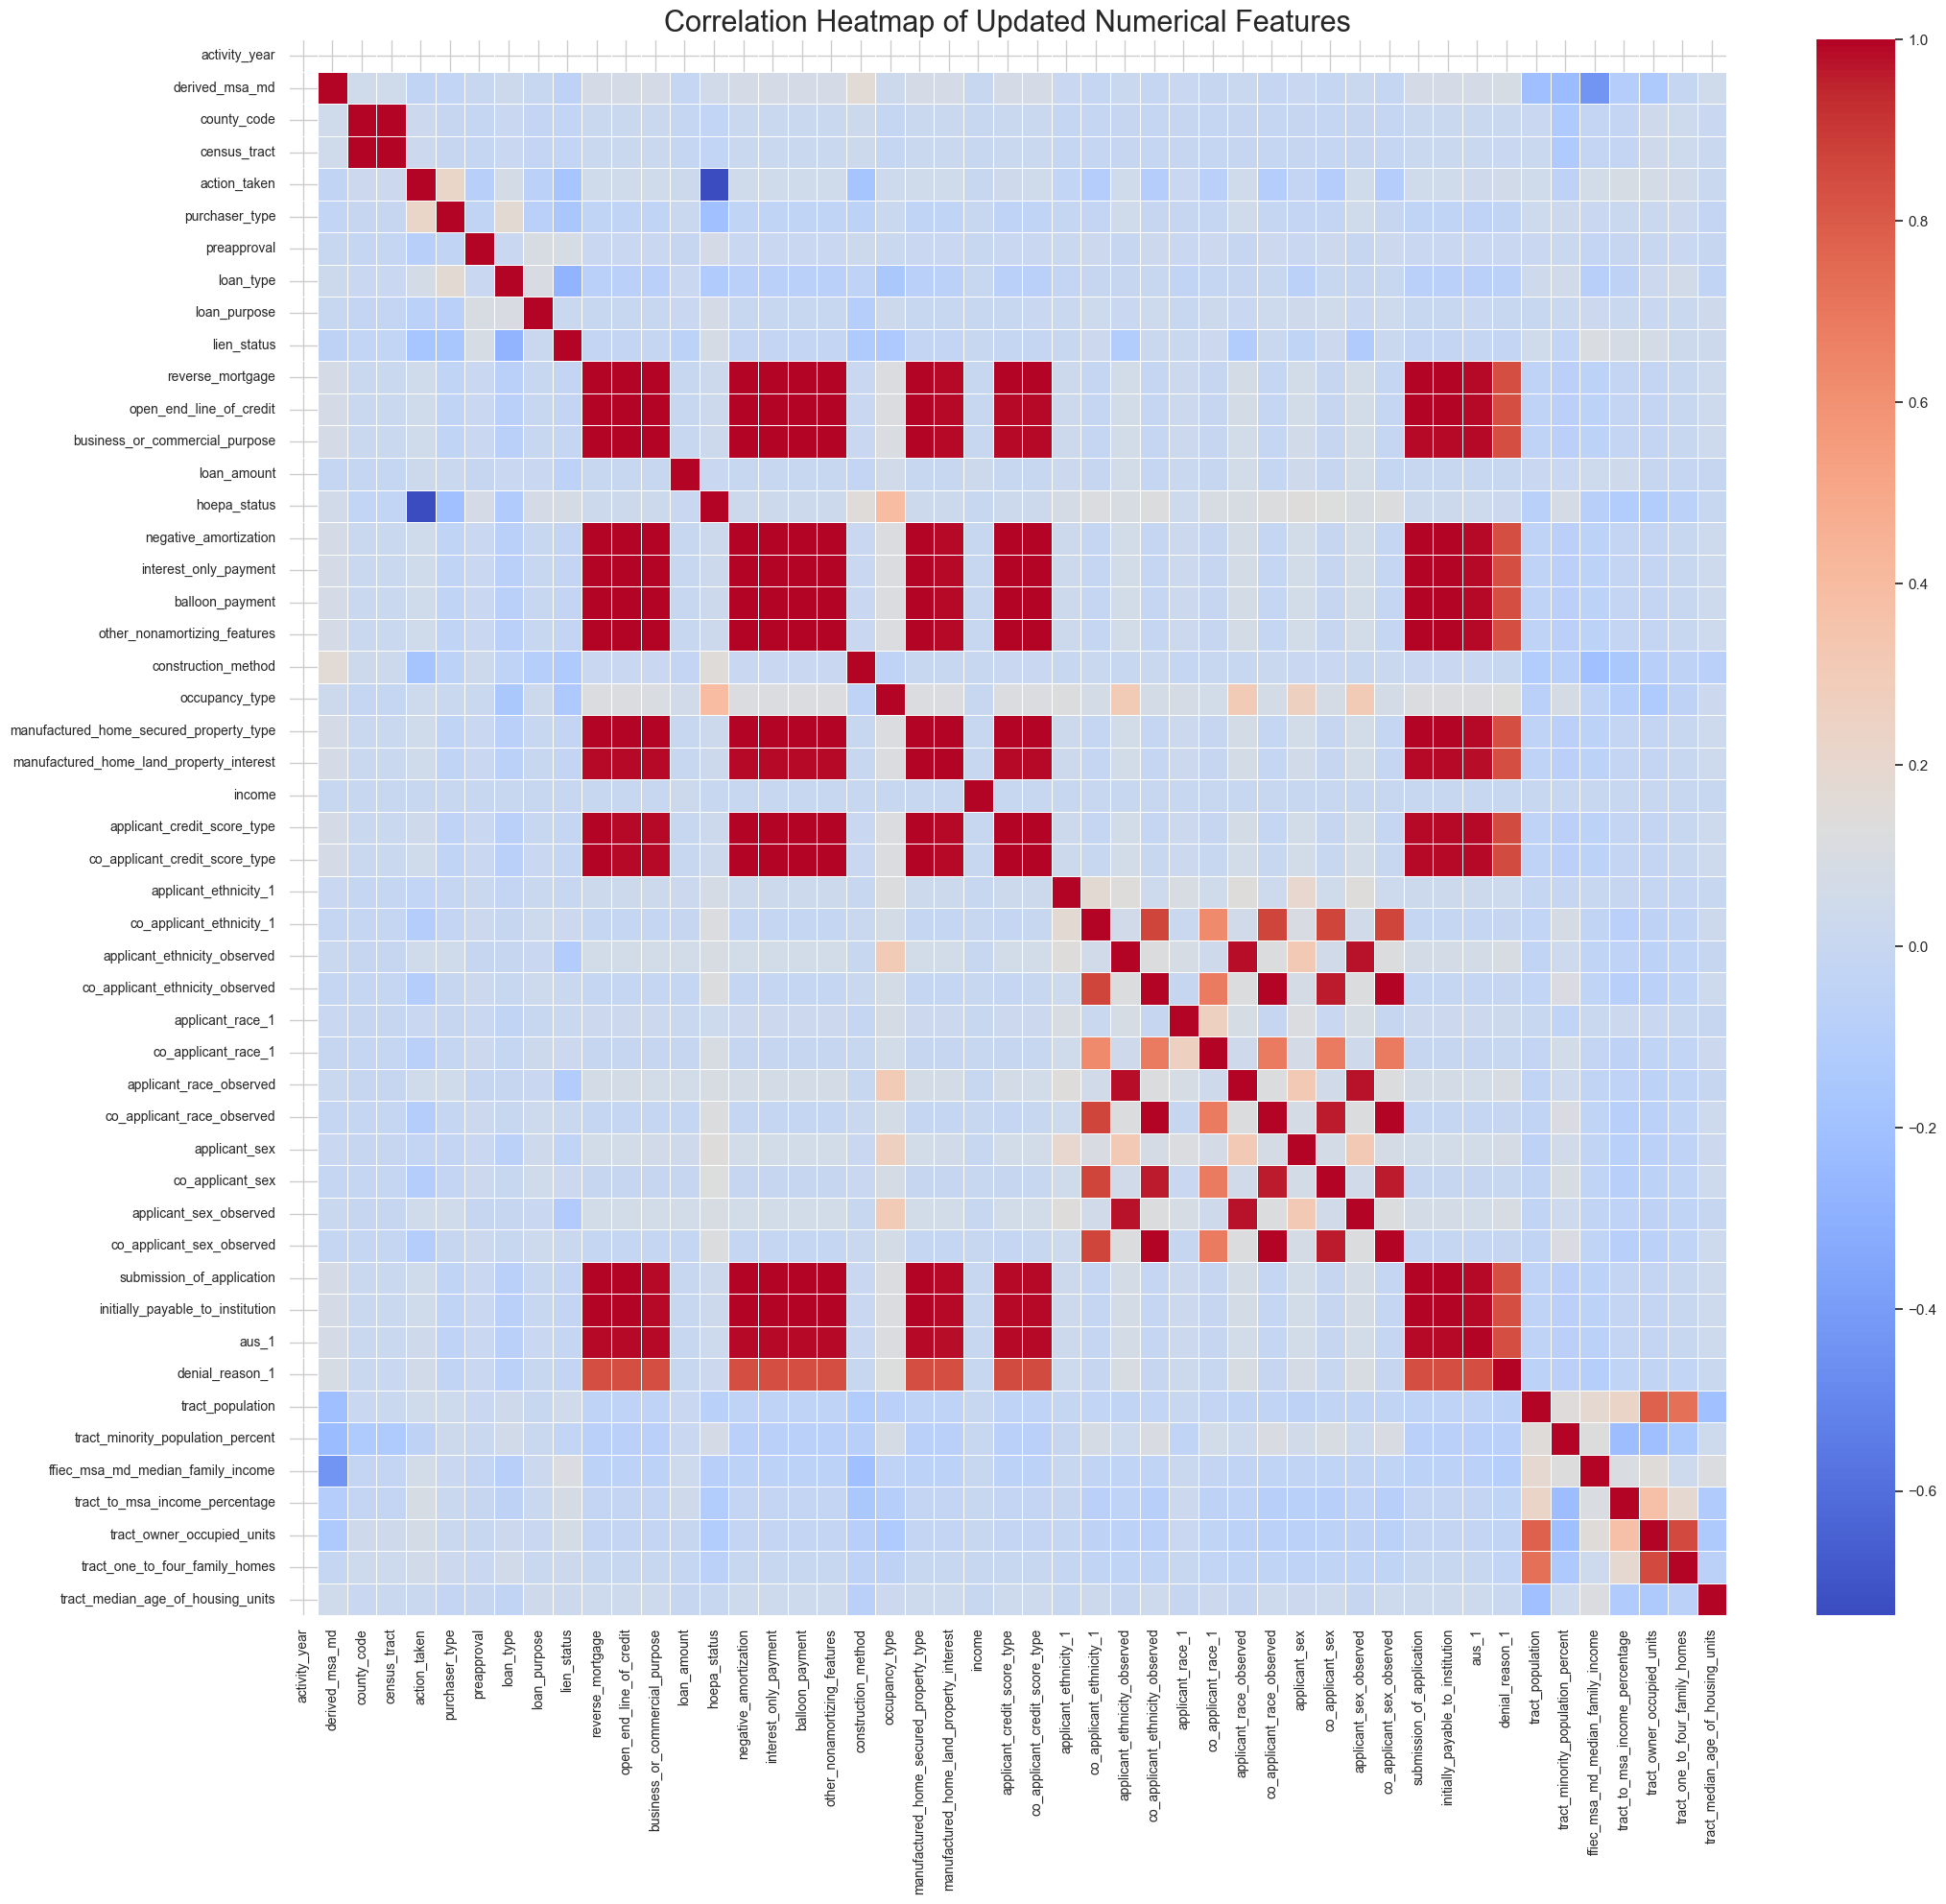

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure df_cleaned is loaded
# project_root = Path.cwd()
# if project_root.name == "notebooks":
#     project_root = project_root.parent

# PROCESSED_DIR = project_root / "data" / "processed"
# processed_file = PROCESSED_DIR / "hmda_lar_2024_cleaned.csv"
# df_cleaned = pd.read_csv(processed_file, low_memory=False)

numerical_cols_updated = df_cleaned.select_dtypes(include=np.number).columns
corr_matrix_updated = df_cleaned[numerical_cols_updated].corr()

plt.figure(figsize=(22, 20))
sns.heatmap(corr_matrix_updated, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Updated Numerical Features', fontsize=22)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

This visualization provides insights into the relationships and dependencies between various numerical attributes in the dataset after dropping columns with high percentages of missing values.

### Missing Value Imputation

Now that we've identified the numerical columns with remaining missing values, we'll impute them using the median. Median imputation is chosen to handle potential outliers and skewed distributions more effectively than mean imputation.

In [12]:


try:
    df_cleaned = pd.read_csv(processed_file, low_memory=False)
    print("df_cleaned re-loaded for imputation.")
except Exception as e:
    print(f"Error loading cleaned data from {processed_file}: {e}")
    print("Please ensure the data preprocessing step (running the 'main()' function in the setup section) has completed successfully.")
    # If loading fails, we cannot proceed, so set df_cleaned to None
    df_cleaned = None

if df_cleaned is None:
    print("Cannot proceed with imputation as df_cleaned could not be loaded.")
else:
    # Identify numerical columns with missing values again
    # This ensures we are working with the current state of df_cleaned
    missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100
    numerical_missing_cols = df_cleaned.select_dtypes(include=np.number).columns[
        missing_percentage[df_cleaned.select_dtypes(include=np.number).columns] > 0
    ].tolist()

    print(f"Columns to impute with median: {numerical_missing_cols}")

    # Perform median imputation
    for col in numerical_missing_cols:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"Imputed column '{col}' with median value: {median_val}")

    # Verify no more missing values in these columns
    missing_after_imputation = df_cleaned[numerical_missing_cols].isnull().sum()
    print("\nMissing values in imputed columns after imputation:")
    print(missing_after_imputation[missing_after_imputation > 0])

    if missing_after_imputation.sum() == 0:
        print("All specified numerical columns have been successfully imputed.")
    else:
        print("Warning: Some missing values still remain in the specified numerical columns.")

    # Display a summary of df_cleaned to show changes
    print("\nDataFrame info after imputation:")
    df_cleaned.info()

df_cleaned re-loaded for imputation.
Columns to impute with median: ['county_code', 'census_tract', 'income', 'applicant_ethnicity_1', 'applicant_ethnicity_2', 'applicant_ethnicity_3', 'applicant_ethnicity_4', 'applicant_ethnicity_5', 'co_applicant_ethnicity_1', 'co_applicant_ethnicity_2', 'co_applicant_ethnicity_3', 'co_applicant_ethnicity_4', 'co_applicant_ethnicity_5', 'applicant_race_1', 'applicant_race_2', 'applicant_race_3', 'applicant_race_4', 'applicant_race_5', 'co_applicant_race_1', 'co_applicant_race_2', 'co_applicant_race_3', 'co_applicant_race_4', 'co_applicant_race_5', 'aus_2', 'aus_3', 'aus_4', 'aus_5', 'denial_reason_2', 'denial_reason_3', 'denial_reason_4']
Imputed column 'county_code' with median value: 27131.0
Imputed column 'census_tract' with median value: 27123041601.0
Imputed column 'income' with median value: 104.0
Imputed column 'applicant_ethnicity_1' with median value: 2.0
Imputed column 'applicant_ethnicity_2' with median value: 11.0
Imputed column 'applican

## Business and Governance Objective

### Predictive Objective

Build a reproducible binary classifier that can distinguish between positive and negative mortgage action outcomes with acceptable predictive performance.

## End-to-End Responsible ML Pipeline
Run the repository pipeline script after the cleaned file exists in `data/processed/hmda_lar_2024_cleaned.csv`.
This exports model artifacts, fairness tables, robustness outputs, and governance documentation.

In [13]:
from pathlib import Path
import subprocess
import sys

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

cmd = [
    sys.executable,
    str(project_root / "scripts" / "run_capstone_pipeline.py"),
    "--project-root",
    str(project_root),
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: /opt/anaconda3/envs/chat-env/bin/python /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/scripts/run_capstone_pipeline.py --project-root /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project


/Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/scripts/run_capstone_pipeline.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=frac, random_state=42))


Sampled dataset to 300000 rows for tractable training.


/opt/anaconda3/envs/chat-env/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['applicant_ethnicity_5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/envs/chat-env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/chat-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/chat-env/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['applicant_ethnicity_5']. At least one non-missing value is needed for imputation with strategy='median'.
  warni

Pipeline complete.
Selected model: random_forest
Artifacts written to: /Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/reports


CompletedProcess(args=['/opt/anaconda3/envs/chat-env/bin/python', '/Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project/scripts/run_capstone_pipeline.py', '--project-root', '/Users/boratonaj/Documents/GWU_Study_Course/Spring_Class_2026/responsible_AI/Group_5_Capstone_Project'], returncode=0)